This notebook is used to process campaign supersaturation/humidity data.

Campaigns from 500k dataset w/ environmental data:  
- ARM: https://www.arm.gov/research/campaigns/sgp2000sprcloud
- CRYSTAL-FACE NASA: https://espoarchive.nasa.gov/archive/browse/crystalf/WB57
- CRYSTAL-FACE UND: https://espoarchive.nasa.gov/archive/browse/crystalf/Citation
- MC3E: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmmc3e-1
- MIDCIX: https://espoarchive.nasa.gov/archive/browse/midcix/WB57
- MPACE: water vapor measurements had issues. 

Other campaigns:
- OLYMPEX: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmolyx-1 (last access: 1/12/26)  

In [11]:
import pandas as pd
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import polars as pl
import umap
import glob

In [2]:
env_data_path = '../data/combined_campaign_env_data.csv'
df_cocpit = pd.read_csv(env_data_path)
df_cocpit.head()

,index,filename,date,Frame Width [pixels],Frame Height [pixels],Particle Width [micrometers],Particle Height [micrometers],Cutoff [%],Aggregate [%],Budding [%],...,Altitude [m],Pressure [hPa],Temperature [C],Ice Water Content [g/m3],PSD IWC [g/m3],concentration ratio,area ratio,mass ratio,Campaign,Perimeter [pixels]
0,271,2000_0309_193624_939_28.png,2000-03-09 19:36:24,106.0,140.0,174.632,248.420,0.00,12.598,78.102,...,8847.020703,314.452612,-44.526981,0.020192,0.040985,0.000000,0.000000,0.000000,ARM,NaN
1,6544,2000_0312_235820_253_18.png,2000-03-12 23:58:20,205.0,228.0,405.842,475.640,0.00,0.030,0.000,...,5489.247559,505.781403,-21.561199,0.142520,0.095309,0.000226,0.007562,0.010116,ARM,NaN
2,14959,2000_0313_195433_318_7.png,2000-03-13 19:54:33,232.0,202.0,411.359,441.451,0.00,0.000,0.000,...,8501.253711,330.897675,-44.473520,0.021264,0.024126,0.000000,0.000000,0.000000,ARM,NaN
3,561,2000_0309_200021_189_43.png,2000-03-09 20:00:21,88.0,97.0,137.014,171.312,0.00,0.000,0.002,...,8538.226562,329.106384,-41.710745,0.026756,0.066655,0.000000,0.000000,0.000000,ARM,NaN
4,18005,2000_0313_203846_761_13.png,2000-03-13 20:38:46,275.0,323.0,546.286,653.653,2.26,2.794,0.231,...,7008.998828,410.059528,-31.873159,0.156208,0.101433,0.001189,0.033566,0.050216,ARM,NaN


In [3]:
# Ensure timestamp in datetime and rename
df_cocpit['Timestamp'] = pd.to_datetime(df_cocpit['date'], errors='coerce')

In [4]:
df_cocpit.shape

(759632, 49)

In [8]:
# number of unique filenames in df
df_cocpit['filename'].nunique()

759626

Note: the total number is actually >700k. Not sure where 

In [6]:
# Assuming your summary dataframe has datetime columns
summary['Earliest'] = pd.to_datetime(summary['Earliest'])
summary['Latest'] = pd.to_datetime(summary['Latest'])

# Compute the campaign duration
summary['Duration'] = summary['Latest'] - summary['Earliest']

# Function to format duration nicely
def format_duration(td):
    days = td.days
    seconds = td.seconds
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = (seconds % 60)
    return f"{days}d {hours}h {minutes}m {secs}s"

# Apply formatting
summary['Campaign_Length'] = summary['Duration'].apply(format_duration)

print(summary[['Earliest', 'Latest', 'Campaign_Length']])


                             Earliest              Latest  Campaign_Length
Campaign                                                                  
ARM               2000-03-09 18:57:35 2000-03-19 15:45:03   9d 20h 47m 28s
CRYSTAL_FACE_NASA 2002-07-09 15:34:18 2002-07-29 20:12:55   20d 4h 38m 37s
CRYSTAL_FACE_UND  2002-07-03 17:30:06 2002-07-29 20:50:15    26d 3h 20m 9s
MC3E              2011-05-23 16:35:05 2011-06-02 12:26:08    9d 19h 51m 3s
MIDCIX            2004-04-19 17:03:29 2004-05-06 20:36:07   17d 3h 32m 38s
MPACE             2004-09-30 01:01:20 2004-10-21 23:57:15  21d 22h 55m 55s


# ARM

Data source: https://www.arm.gov/research/campaigns/sgp2000sprcloud (last access: 1/13/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/ARM

In [7]:
data_dir = "/home/jko/ssl-cpi-analysis/data/env/ARM"
filepaths = sorted(glob.glob(os.path.join(data_dir, "*.t4archive.gz")))

# ---------------------------
# Decode YYMMDD → datetime
# ---------------------------
def decode_date(d):
    """
    d is integer YYMMDD.
    ARM Spring 2000 ⇒ year = 2000 + YY.
    """
    d = int(d)
    year = 2000 + (d // 10000)
    month = (d % 10000) // 100
    day = d % 100
    return pd.Timestamp(year, month, day)

# ---------------------------
# Column names (your mapping)
# ---------------------------
columns = [
    "Date",
    "Time(sec)",
    "True Air Speed (m/s)",
    "Wind Speed (m/s)",
    "Wind Direction (deg)",
    "INS Heading (deg)",
    "Pitch (deg)",
    "Roll (deg)",
    "Static Pressure (mb)",
    "Pressure Altitude (m)",
    "Air Temp Rosemount (C)",
    "Dew Point EG&G (C)",
    "Dew Point Cryo (C)",
    "Frost Point Cryo (C)",
    "King LWC (g/m3)",
    "FSSP LWC (g/m3)",
    "Vertical Wind (m/s)",
    "Turbulence (eps^(1/3))",
    "Ozone (ppb)",
    "CN Conc (#/cm3)",
    "INS Latitude (deg)",
    "INS Longitude (deg)",
    "GPS Lat (deg)",
    "GPS Lon (deg)",
    "GPS Alt (m)",
    "GPS Ground Speed (m/s)",
    "FSSP Conc (#/ml)",
    "FSSP Mean Diam (µm)",
    "FSSP Mean Vol Diam (µm)",
    "1DC Conc (#/L)",
    "1DC Mean Diam (µm)",
    "1DC Mean Vol Diam (µm)",
    "2DC Conc (#/L)",
    "2DC Mean Diam (µm)",
    "2DC Mean Vol Diam (µm)",
    "2DC Shadow-Or (#/L)",
    "2DP Conc (#/L)",
    "2DP Mean Diam (µm)",
    "2DP Mean Vol Diam (µm)",
]


# ------------------------------------------------------
# Loader for a single t4archive.gz file (full decoding)
# ------------------------------------------------------
def load_t4archive(filepath):

    with gzip.open(filepath, "rb") as f:
        raw = f.read()

    dtype = ">i4"  # big-endian int32
    record_length = 39

    data = np.frombuffer(raw, dtype=dtype)
    N = data.size // record_length
    data = data.reshape((N, record_length))

    # convert to float
    data_float = data.astype(float)
    data_float[:, 1:] = data_float[:, 1:] / 1000.0 - 100.0

    df = pd.DataFrame(data_float, columns=columns)

    # decode YYMMDD → yyyy-mm-dd
    df["Date"] = df["Date"].apply(decode_date)

    # combine into full timestamp
    df["Timestamp"] = df["Date"] + pd.to_timedelta(df["Time(sec)"], unit="s")

    # add the source file for diagnostics
    df["source_file"] = os.path.basename(filepath)

    return df


# ---------------------------
# Load all files
# ---------------------------
df_all = pd.concat([load_t4archive(fp) for fp in filepaths], ignore_index=True)

print("Total combined records:", len(df_all))
df_all.head()

Total combined records: 429040


,Date,Time(sec),True Air Speed (m/s),Wind Speed (m/s),Wind Direction (deg),INS Heading (deg),Pitch (deg),Roll (deg),Static Pressure (mb),Pressure Altitude (m),...,1DC Mean Vol Diam (µm),2DC Conc (#/L),2DC Mean Diam (µm),2DC Mean Vol Diam (µm),2DC Shadow-Or (#/L),2DP Conc (#/L),2DP Mean Diam (µm),2DP Mean Vol Diam (µm),Timestamp,source_file
0,2000-03-09,66670.00,17.514,-99.0,312.428,5.1,0.307,-0.528,982.754,256.990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.000,citation.0309001831.t4archive.gz
1,2000-03-09,66670.25,17.414,-99.0,321.000,5.1,0.307,-0.528,982.768,256.874,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.250,citation.0309001831.t4archive.gz
2,2000-03-09,66670.50,17.426,-99.0,321.000,5.1,0.307,-0.528,982.742,257.101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.500,citation.0309001831.t4archive.gz
3,2000-03-09,66670.75,17.167,-99.0,321.000,5.1,0.307,-0.528,982.763,256.918,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.750,citation.0309001831.t4archive.gz
4,2000-03-09,66671.00,17.225,-99.0,312.428,5.1,0.307,-0.528,982.754,256.990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:11.000,citation.0309001831.t4archive.gz


In [9]:
# Compute supersaturation wrt ice from frost point in celsius

# Murphy & Koop (2005) saturation vapor pressure over ice
def es_ice_MK(T):
    """
    Saturation vapor pressure over ice (Pa)
    T in Kelvin
    """
    return np.exp(
        9.550426 
        - 5723.265 / T 
        + 3.53068 * np.log(T) 
        - 0.00728332 * T
    )

def compute_Si(frost_point_C, temperature_C):
    """
    frost_point_C : frost point in Celsius
    temperature_C : ambient air temperature in Celsius
    returns supersaturation with respect to ice Si (unitless)
    """
    Tf = frost_point_C + 273.15
    T  = temperature_C + 273.15
    
    # actual vapor pressure from frost point
    e = es_ice_MK(Tf)
    
    # saturation vapor pressure over ice at ambient temperature
    esi = es_ice_MK(T)
    
    # supersaturation
    Si = e / esi - 1
    return Si
df_all["Si"] = compute_Si(df_all["Frost Point Cryo (C)"], df_all["Air Temp Rosemount (C)"])

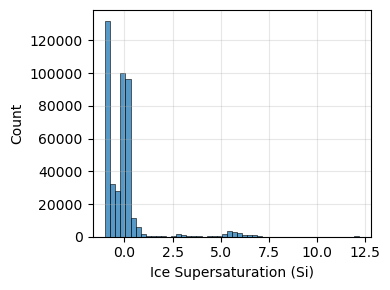

In [10]:
# distribution of Si
fp = df_all["Si"].dropna()
plt.figure(figsize=(4,3))
sns.histplot(fp, bins=50, kde=False)
plt.xlabel("Ice Supersaturation (Si)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
data_dir = '/home/jko/ssl-cpi-analysis/data/env/ARM'
filename = '/home/jko/ssl-cpi-analysis/data/env/ARM/citation.0309001831.t4archive.gz'
filepath = os.path.join(data_dir, filename)

In [ ]:

# open the gzipped binary file
with gzip.open(filepath, "rb") as f:
    raw = f.read()

# each record has 39 int32 values
record_length = 39
# dtype = np.int32
dtype = '>i4'

# interpret raw bytes as a flat array of int32
data = np.frombuffer(raw, dtype=dtype)

# reshape into (N_records, 39)
N = data.size // record_length
data = data.reshape((N, record_length))

print("Total records:", N)

In [ ]:
# copy to float array
data_float = data.astype(float)

# convert columns 2–38
data_float[:, 1:] = data_float[:, 1:] / 1000.0 - 100.0

# define dataframe columns
columns = [
    "Date",
    "Time(sec)",
    "True Air Speed (m/s)",
    "Wind Speed (m/s)",
    "Wind Direction (deg)",
    "INS Heading (deg)",
    "Pitch (deg)",
    "Roll (deg)",
    "Static Pressure (mb)",
    "Pressure Altitude (m)",
    "Air Temp Rosemount (C)",
    "Dew Point EG&G (C)",
    "Dew Point Cryo (C)",
    "Frost Point Cryo (C)",
    "King LWC (g/m3)",
    "FSSP LWC (g/m3)",
    "Vertical Wind (m/s)",
    "Turbulence (eps^(1/3))",
    "Ozone (ppb)",
    "CN Conc (#/cm3)",
    "INS Latitude (deg)",
    "INS Longitude (deg)",
    "GPS Lat (deg)",
    "GPS Lon (deg)",
    "GPS Alt (m)",
    "GPS Ground Speed (m/s)",
    "FSSP Conc (#/ml)",
    "FSSP Mean Diam (µm)",
    "FSSP Mean Vol Diam (µm)",
    "1DC Conc (#/L)",
    "1DC Mean Diam (µm)",
    "1DC Mean Vol Diam (µm)",
    "2DC Conc (#/L)",
    "2DC Mean Diam (µm)",
    "2DC Mean Vol Diam (µm)",
    "2DC Shadow-Or (#/L)",
    "2DP Conc (#/L)",
    "2DP Mean Diam (µm)",
    "2DP Mean Vol Diam (µm)",
]

# convert to pandas df
df = pd.DataFrame(data_float, columns=columns)
df.head()

In [ ]:
# convert date YYMMDD → datetime
def decode_date(d):
    year  = 2000 + int(d // 10000)   # YY → 20YY since campaign is in 2000
    month = int((d % 10000) // 100)
    day   = int(d % 100)
    return pd.Timestamp(year, month, day)

df["Date"] = df["Date"].apply(decode_date)

# time in seconds from midnight
df["Timestamp"] = df["Date"] + pd.to_timedelta(df["Time(sec)"], unit="s")

In [ ]:
df.head()

In [ ]:
# plot distribution of frost point (most relevant to humidity wrt ice)
fp = df["Frost Point Cryo (C)"].dropna()
plt.figure(figsize=(4,3))
sns.histplot(fp, bins=50, kde=False)
plt.xlabel("Frost Point (°C)")
plt.ylabel("Count")
plt.title("Distribution of Cryogenic Frost Point")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Compute supersaturation wrt ice from frost point in celsius

# Murphy & Koop (2005) saturation vapor pressure over ice
def es_ice_MK(T):
    """
    Saturation vapor pressure over ice (Pa)
    T in Kelvin
    """
    return np.exp(
        9.550426 
        - 5723.265 / T 
        + 3.53068 * np.log(T) 
        - 0.00728332 * T
    )

def compute_Si(frost_point_C, temperature_C):
    """
    frost_point_C : frost point in Celsius
    temperature_C : ambient air temperature in Celsius
    returns supersaturation with respect to ice Si (unitless)
    """
    Tf = frost_point_C + 273.15
    T  = temperature_C + 273.15
    
    # actual vapor pressure from frost point
    e = es_ice_MK(Tf)
    
    # saturation vapor pressure over ice at ambient temperature
    esi = es_ice_MK(T)
    
    # supersaturation
    Si = e / esi - 1
    return Si
df["Si"] = compute_Si(df["Frost Point Cryo (C)"], df["Air Temp Rosemount (C)"])

In [ ]:
# distribution of Si
fp = df["Si"].dropna()
plt.figure(figsize=(4,3))
sns.histplot(fp, bins=50, kde=False)
plt.xlabel("Ice Supersaturation (Si)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot distribution air temperature
fp = df["Air Temp Rosemount (C)"].dropna()
plt.figure(figsize=(4,3))
sns.histplot(fp, bins=50, kde=False)
plt.xlabel("Air Temp (degC)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Validating temperatures & making sure that timestamps are in the same UTC timezone.

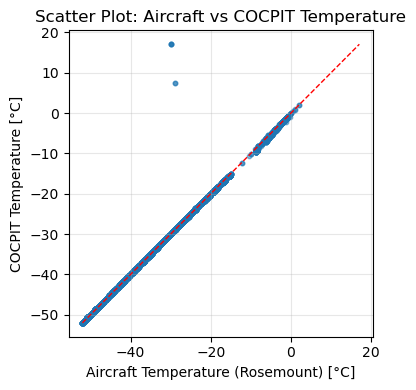

In [13]:
# compare temperatures from COCPIT env and from raw data
df=df_all
cocpit_cols = ['Timestamp', 'Temperature [C]']
raw_cols = ['Timestamp', 'Air Temp Rosemount (C)']
ta_cocpit = df_cocpit[cocpit_cols]
ta_raw = df[raw_cols]
ta_cocpit = df_cocpit.rename(columns={"Temperature [C]": "T_cocpit"})
ta_raw = df.rename(columns={"Air Temp Rosemount (C)": "T_aircraft"})
# ta_cocpit["Timestamp"] = pd.to_datetime(ta_cocpit["Timestamp"], errors='coerce')
# ta_raw["Timestamp"]    = pd.to_datetime(ta_raw["Timestamp"], errors='coerce')
merged = pd.merge(ta_raw, ta_cocpit, on="Timestamp", how="inner")
merged = merged[
    (merged["T_aircraft"] > -90) &
    (merged["T_aircraft"] < 40) &
    (merged["T_cocpit"] > -90) &
    (merged["T_cocpit"] < 40)
]
plt.figure(figsize=(4,4))

plt.scatter(
    merged["T_aircraft"],
    merged["T_cocpit"],
    s=10, alpha=0.5
)

plt.xlabel("Aircraft Temperature (Rosemount) [°C]")
plt.ylabel("COCPIT Temperature [°C]")
plt.title("Scatter Plot: Aircraft vs COCPIT Temperature")

# 1:1 reference line
min_val = min(merged["T_aircraft"].min(), merged["T_cocpit"].min())
max_val = max(merged["T_aircraft"].max(), merged["T_cocpit"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# load CPI-21K data
feat_path = '/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/CPI21K-CLS-Features/trainfeat.pth'
labels_path = '/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/CPI21K-CLS-Features/trainlabels.pth'
trainfeat = torch.load(feat_path, map_location="cpu")
trainlabels = torch.load(labels_path, map_location="cpu")

In [ ]:
df_trainfeat = pd.DataFrame(trainfeat.numpy())
print(df_trainfeat.shape)
df_trainfeat.head()

In [ ]:
df_trainlabels = pd.DataFrame(trainlabels.numpy())
print(df_trainlabels.shape)
df_trainlabels.head()

In [ ]:
# load corresponding filenames
filelist_train = pd.read_csv('/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/CPI21K-CLS-Features/filelist_train.txt', header=None)
filelist_train.rename(columns={filelist_train.columns[0]: "path"}, inplace=True)
splits = filelist_train["path"].str.split("/", expand=True)
filelist_train["filename"] = splits.iloc[:, -1]   # last element
filelist_train["habit"]    = splits.iloc[:, -2]   # second-to-last
filelist_train = filelist_train.reset_index().rename(columns={"index": "idx"})
filelist_train

In [ ]:
temp = filelist_train
count_2000 = temp["filename"].str.startswith("2000_").sum()
print(count_2000)

In [ ]:
filelist_train_merged = filelist_train.merge(
    df_cocpit[["filename", "Campaign", "Timestamp"]],
    on="filename",
    how="inner"
)
print(filelist_train.shape)
print(filelist_train_merged.shape)

In [ ]:
df_cocpit[df_cocpit['Campaign']=='ARM'].shape

In [ ]:
temp = filelist_train_merged
temp[temp['Campaign']=='ARM']

For some reason, very small sample of ARM data in CPI-21K. Going to try using CPI-3M for analysis below with ARM data.

In [17]:
# load cpi3m embeddings (from SSL Model v3)
cpi3m_path = '/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet'
scan = pl.scan_parquet(cpi3m_path)
# filter by campaign == "ARM"
cpi3m_arm = (
    scan
    .filter(pl.col("campaign") == "ARM")
    .collect()
)
print(type(cpi3m_arm))
print(cpi3m_arm.head())
# cpi3m = pd.read_parquet(cpi3m_path)
# cpi3m_arm = cpi3m[cpi3m['Campaign']=='ARM']
# cpi3m_arm.shape

<class 'polars.dataframe.frame.DataFrame'>
shape: (5, 5)
┌────────────────────────┬──────────────┬──────────┬───────────────────────┬───────────────────────┐
│ campaign_file_id       ┆ cls_features ┆ campaign ┆ filename              ┆ head_features         │
│ ---                    ┆ ---          ┆ ---      ┆ ---                   ┆ ---                   │
│ str                    ┆ list[f32]    ┆ str      ┆ str                   ┆ list[f32]             │
╞════════════════════════╪══════════════╪══════════╪═══════════════════════╪═══════════════════════╡
│ ARM/2000_0306_202027_5 ┆ [1.024477,   ┆ ARM      ┆ 2000_0306_202027_531_ ┆ [0.06622, -0.005036,  │
│ 31_20.pn…              ┆ 1.715163, …  ┆          ┆ 20.png                ┆ … -0.0933…            │
│                        ┆ 1.07379…     ┆          ┆                       ┆                       │
│ ARM/2000_0306_202027_5 ┆ [0.983172,   ┆ ARM      ┆ 2000_0306_202027_531_ ┆ [0.053725, 0.029565,  │
│ 31_27.pn…              ┆ 0.97981

In [104]:
import umap
# UMAP to reduce CLS to 3-dimensions
temp = cpi3m_arm.sample(n=100000, seed=42)
X = temp['cls_features'].to_list()
X = np.array(X, dtype=np.float32)
print("Embedding matrix:", X.shape)
# Run UMAP → 3 dimensions
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=100,
    min_dist=0.1,
    metric="cosine",
    n_jobs=-1
    # random_state=42,
)

X_umap = umap_model.fit_transform(X)
print("UMAP shape:", X_umap.shape)
# (N, 3)

Embedding matrix: (100000, 384)
UMAP shape: (100000, 3)


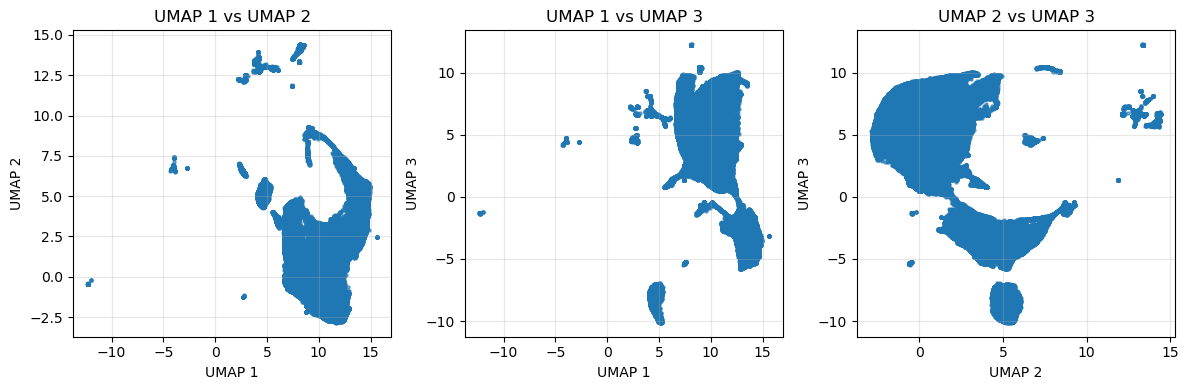

In [105]:
# plot UMAP in 3D
# Convert to named columns for clarity
umap1 = X_umap[:, 0]
umap2 = X_umap[:, 1]
umap3 = X_umap[:, 2]

# Create figure with 3 subplots
plt.figure(figsize=(12, 4))

# ---- Plot 1: UMAP1 vs UMAP2 ----
plt.subplot(1, 3, 1)
plt.scatter(umap1, umap2, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP 1 vs UMAP 2")
plt.grid(alpha=0.3)

# ---- Plot 2: UMAP1 vs UMAP3 ----
plt.subplot(1, 3, 2)
plt.scatter(umap1, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 3")
plt.title("UMAP 1 vs UMAP 3")
plt.grid(alpha=0.3)

# ---- Plot 3: UMAP2 vs UMAP3 ----
plt.subplot(1, 3, 3)
plt.scatter(umap2, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 2")
plt.ylabel("UMAP 3")
plt.title("UMAP 2 vs UMAP 3")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [106]:
# normalize UMAP embeddings to RGB
# Assume X_umap is (N, 3)
umap_norm = (X_umap - X_umap.min(axis=0)) / (X_umap.max(axis=0) - X_umap.min(axis=0))
umap_norm = np.clip(umap_norm, 0, 1)       # safety

# Convert to 0–255 uint8 RGB
rgb = (umap_norm * 255).astype(np.uint8)

print(rgb.shape)   # (N, 3)

(100000, 3)


In [107]:
# get timestamps from filenames
# Extract as a Pandas Series
fname_pd = temp.select("filename").to_pandas()["filename"]

def filename_to_timestamp(fname):
    base = "_".join(fname.split("_")[:3])  # keep YYYY_MMDD_HHMMSS
    dt = pd.to_datetime(base, format="%Y_%m%d_%H%M%S")
    return dt

timestamps = fname_pd.apply(filename_to_timestamp)
timestamps

0       2000-03-18 23:01:23
1       2000-03-13 00:28:48
2       2000-03-19 17:13:58
3       2000-03-18 22:52:34
4       2000-03-18 22:58:58
                ...        
99995   2000-03-19 18:43:21
99996   2000-03-18 23:00:05
99997   2000-03-13 00:38:59
99998   2000-03-19 17:43:40
99999   2000-03-13 21:09:55
Name: filename, Length: 100000, dtype: datetime64[ns]

In [108]:
# add associated timestamp to rgb
rgb_df = pd.DataFrame(
    rgb,
    columns=["R", "G", "B"]
)
df_rgb = pd.DataFrame({"Timestamp": timestamps}).reset_index(drop=True)
df_rgb = pd.concat([df_rgb, rgb_df], axis=1)

In [109]:
# filter environmental data to reasonable range
env = df_all[(df_all['Si']<1.0) & (df_all['Si']>-0.9)]
env.head()

,Date,Time(sec),True Air Speed (m/s),Wind Speed (m/s),Wind Direction (deg),INS Heading (deg),Pitch (deg),Roll (deg),Static Pressure (mb),Pressure Altitude (m),...,2DC Conc (#/L),2DC Mean Diam (µm),2DC Mean Vol Diam (µm),2DC Shadow-Or (#/L),2DP Conc (#/L),2DP Mean Diam (µm),2DP Mean Vol Diam (µm),Timestamp,source_file,Si
0,2000-03-09,66670.00,17.514,-99.0,312.428,5.1,0.307,-0.528,982.754,256.990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.000,citation.0309001831.t4archive.gz,-0.484335
1,2000-03-09,66670.25,17.414,-99.0,321.000,5.1,0.307,-0.528,982.768,256.874,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.250,citation.0309001831.t4archive.gz,-0.484814
2,2000-03-09,66670.50,17.426,-99.0,321.000,5.1,0.307,-0.528,982.742,257.101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.500,citation.0309001831.t4archive.gz,-0.485816
3,2000-03-09,66670.75,17.167,-99.0,321.000,5.1,0.307,-0.528,982.763,256.918,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:10.750,citation.0309001831.t4archive.gz,-0.486804
4,2000-03-09,66671.00,17.225,-99.0,312.428,5.1,0.307,-0.528,982.754,256.990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000-03-09 18:31:11.000,citation.0309001831.t4archive.gz,-0.487471


In [110]:
# 1. Add an index to preserve original order
ts_df = pd.DataFrame({
    "Timestamp_query": timestamps,
    "orig_order": range(len(timestamps))
})

# 2. Sort copies for merge_asof (required)
ts_sorted = ts_df.sort_values("Timestamp_query")
env_sorted = env.sort_values("Timestamp")

# 3. Perform nearest match
matched_env = pd.merge_asof(
    ts_sorted,
    env_sorted,
    left_on="Timestamp_query",
    right_on="Timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1s")
)

# 4. Restore original order
matched_env = matched_env.sort_values("orig_order").reset_index(drop=True)

# 5. Drop helper column if you want
matched_env = matched_env.drop(columns=["orig_order"])

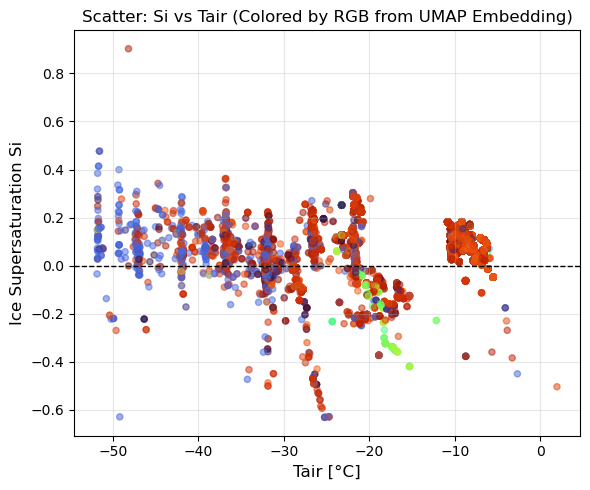

In [117]:
import colorsys
df_env_final = matched_env[['Timestamp', 'Si', 'Air Temp Rosemount (C)']]
df_final = df_rgb.merge(df_env_final, on='Timestamp', how='inner')

df_final = df_final.rename(columns={
    "Air Temp Rosemount (C)": "Tair"
})

# Pick random points (adjust as needed)
df_plot = df_final.sample(n=10000, random_state=42)

# Convert RGB columns (0–255 ints) to 0–1 floats
rgb_vals = df_plot[["R", "G", "B"]].values / 255.0


# Convert RGB → HSV → use H (hue) as scalar for colormap
hsv = np.array([colorsys.rgb_to_hsv(r,g,b) for r,g,b in rgb_vals])
hue = hsv[:,0]   # Range 0..1

# Map hue to a matplotlib colormap
cmap = plt.cm.turbo
colors = cmap(hue)
# colors = rgb_vals

plt.figure(figsize=(6, 5))

plt.scatter(
    df_plot["Tair"],
    df_plot["Si"],
    c=colors,
    s=20,
    alpha=0.5
)
# ★ Horizontal dashed line at Si = 0
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("Tair [°C]", fontsize=12)
plt.ylabel("Ice Supersaturation Si", fontsize=12)
plt.title("Scatter: Si vs Tair (RGB -> colormap from UMAP Embedding)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [118]:
df_final.shape

(1167190, 6)

# CRYSTAL-FACE NASA

Data Source: https://espoarchive.nasa.gov/archive/browse/crystalf/WB57 (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-NASA

In [15]:
import pandas as pd
from pathlib import Path

def parse_columns(header_line):
    tokens = header_line.split()
    cols = []
    i = 0
    while i < len(tokens):
        if i + 1 < len(tokens) and tokens[i + 1].startswith("("):
            cols.append(f"{tokens[i]} {tokens[i + 1]}")
            i += 2
        else:
            cols.append(tokens[i])
            i += 1
    return cols

def read_jlh_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    n_header = int(lines[0].split()[0])

    # FIX: parse columns correctly
    columns = parse_columns(lines[n_header - 1])

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=columns
    )

    df["source_file"] = filepath
    return df


# Directory containing files
data_dir = Path("/home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-NASA")

# Read and combine all files
dfs = [read_jlh_file(f) for f in data_dir.iterdir() if f.is_file()]
combined_df = pd.concat(dfs, ignore_index=True)

print(combined_df.head())


    UT (s)    ppmv  P(mb)   T(K)   Ep(mb)  Td(C)  Esh(mb)  Esi(mb)    %RH  \
0  64803.5  505.90  286.4  237.0  0.14489 -38.97  0.27810  0.19706  73.53   
1  64804.5  473.78  285.9  236.9  0.13545 -39.57  0.27532  0.19491  69.49   
2  64806.5  461.76  284.8  236.8  0.13151 -39.83  0.27256  0.19279  68.21   
3  64807.5  466.62  284.3  236.7  0.13266 -39.75  0.26982  0.19068  69.57   
4  64808.5  467.65  283.8  236.6  0.13272 -39.75  0.26712  0.18860  70.37   

     g/kg                                        source_file  
0  0.3162  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  
1  0.2961  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  
2  0.2886  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  
3  0.2916  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  
4  0.2923  /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FA...  


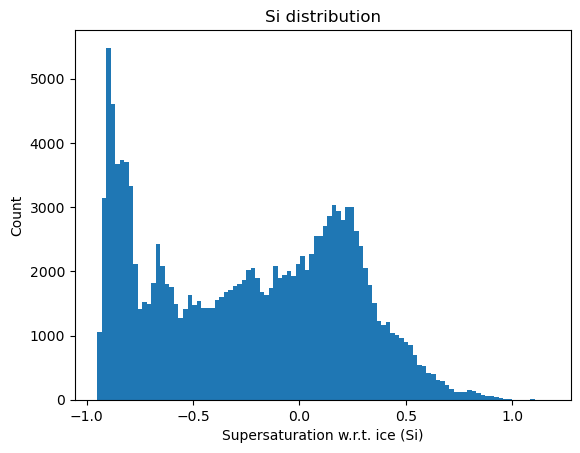

In [16]:
# add supersaturation WRT zero (>0 is supersaturated, <0 is subsaturated)
combined_df["Si"] = combined_df["%RH"] / 100.0 - 1.0

# plot distribution of Si
df = combined_df 
si = df["Si"].dropna()
plt.figure()
plt.hist(si, bins=100)
plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Si distribution")
plt.show()

# CRYSTAL-FACE UND

Data Source: https://espoarchive.nasa.gov/archive/browse/crystalf/Citation (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-UND

In [18]:
import pandas as pd
from pathlib import Path
import re

def clean_col(name):
    name = name.strip()
    name = re.sub(r"[^\w]+", "_", name)
    return name.strip("_")

def read_mis_cit_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    # Number of header lines
    n_header = int(lines[0].split()[0])

    # Column names are two lines before data
    col_line = lines[n_header - 2]

    columns = [clean_col(c) for c in col_line.split()]

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=columns,
        na_values=[999999.9999]
    )

    df["source_file"] = filepath.name
    return df
    
data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-UND')

dfs = [
    read_mis_cit_file(f)
    for f in data_dir.glob("*MIS.CIT")
]

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

,Time,COND_NUCL,FSSP_H2O,LIQ_H2O,ICE_DET,MixingRatio,RH,Ext_Coeff,source_file
0,53800.0,NaN,0.0,NaN,2.1240,11.3337,0.0410,1.7548,ND20020725__MIS.CIT
1,53801.0,NaN,0.0,NaN,2.1243,11.3337,0.0410,1.9484,ND20020725__MIS.CIT
2,53802.0,NaN,0.0,NaN,2.1242,11.3338,0.0409,2.1112,ND20020725__MIS.CIT
3,53803.0,NaN,0.0,NaN,2.1241,11.3338,0.0409,2.2388,ND20020725__MIS.CIT
4,53804.0,NaN,0.0,NaN,2.1241,11.5782,0.0416,2.3490,ND20020725__MIS.CIT


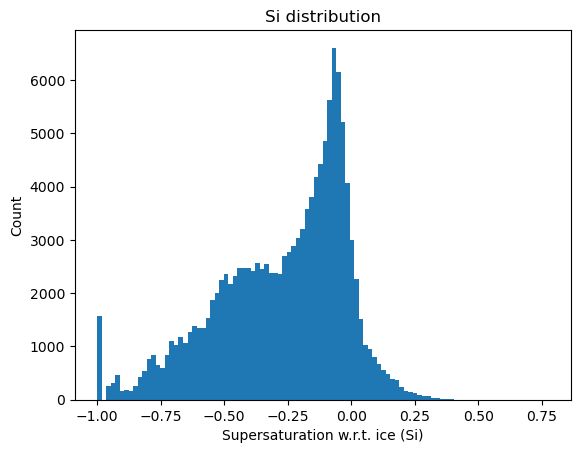

In [20]:
# add supersaturation WRT zero (>0 is supersaturated, <0 is subsaturated)
combined_df["Si"] = combined_df["RH"] / 100.0 - 1.0

# plot distribution of Si
df = combined_df 
si = df["Si"].dropna()
plt.figure()
plt.hist(si, bins=100)
plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Si distribution")
plt.show()

# MC3E

Data Source: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmmc3e-1 (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/MC3E
Note:
- Si is not pre-computed in files. Calculated from vapor mixing ratio, air temperature, and pressure. 

In [21]:
import pandas as pd
import re
from pathlib import Path

def clean_col(name):
    name = name.strip()
    name = re.sub(r"[^\w]+", "_", name)
    return name.strip("_")

def read_und_citation_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    # Number of header lines
    n_header = int(lines[0].split()[0])

    # Column names are two lines before data
    col_line = lines[n_header - 2]
    columns = [clean_col(c) for c in col_line.split()]

    # Read data
    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=columns,
        na_values=[
            999999.9999,
            999.9999999,
            9999.999999,
            99999.99999,
            99999999999,
            999999
        ]
    )

    df["source_file"] = filepath.name
    return df

data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/MC3E')

dfs = [
    read_und_citation_file(f)
    for f in data_dir.iterdir()
    if f.is_file()
]

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

,Time,Air_Temp,MachNo_N,IAS,TAS,Press_Alt,Pot_Temp_T1,Pitot_Wing,CABIN_PRES,STATIC_PR,...,2_DC_EffRad,IceMSOFreq,CPCConc,TSG_Date,source_file,GPS_Lat,GPS_Lon,GPS_Alt,GPS_GSpeed,GPS_GTrack
0,74969.25,29.0487,0.0482,16.0277,16.8035,389.5258,305.0867,1.4990,969.6332,967.2753,...,NaN,NaN,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN
1,74970.25,29.0452,0.0483,16.0550,16.8322,389.6349,305.0844,1.4908,969.6029,967.2626,...,NaN,40050.0,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN
2,74971.25,29.0395,0.0483,16.0548,16.8316,389.4712,305.0769,1.4908,969.6181,967.2816,...,NaN,39990.0,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN
3,74972.25,29.0418,0.0486,16.1482,16.9296,389.5367,305.0799,1.5372,969.6567,967.2740,...,NaN,39990.0,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN
4,74973.25,29.0485,0.0484,16.0880,16.8663,389.1329,305.0824,1.5443,969.5945,967.3208,...,NaN,39990.0,NaN,110527,2011_05_27_11_49_26_v2.mc3e,NaN,NaN,NaN,NaN,NaN


In [22]:
combined_df.columns

Index(['Time', 'Air_Temp', 'MachNo_N', 'IAS', 'TAS', 'Press_Alt',
       'Pot_Temp_T1', 'Pitot_Wing', 'CABIN_PRES', 'STATIC_PR', 'DEWPT',
       'MixingRatio', 'DewPoint', 'FrostPoint', 'POS_Roll', 'POS_Pitch',
       'POS_Head', 'POSZ_Acc', 'POS_Lat', 'POS_Lon', 'POS_Alt', 'POS_Spd',
       'POS_Trk', 'Alpha', 'Beta', 'VERT_VEL', 'Wind_Z', 'Wind_M', 'Wind_D',
       'TURB', 'King_LWC_ad', 'Nev_TWC', 'Nev_LWCcor', 'CDP_Conc', 'CDP_LWC',
       'CDP_MenD', 'CDP_VolDia', 'CDP_EffRad', '2_DC_Conc', '2_DC_MenD',
       '2_DC_VolDia', '2_DC_EffRad', 'IceMSOFreq', 'CPCConc', 'TSG_Date',
       'source_file', 'GPS_Lat', 'GPS_Lon', 'GPS_Alt', 'GPS_GSpeed',
       'GPS_GTrack'],
      dtype='object')

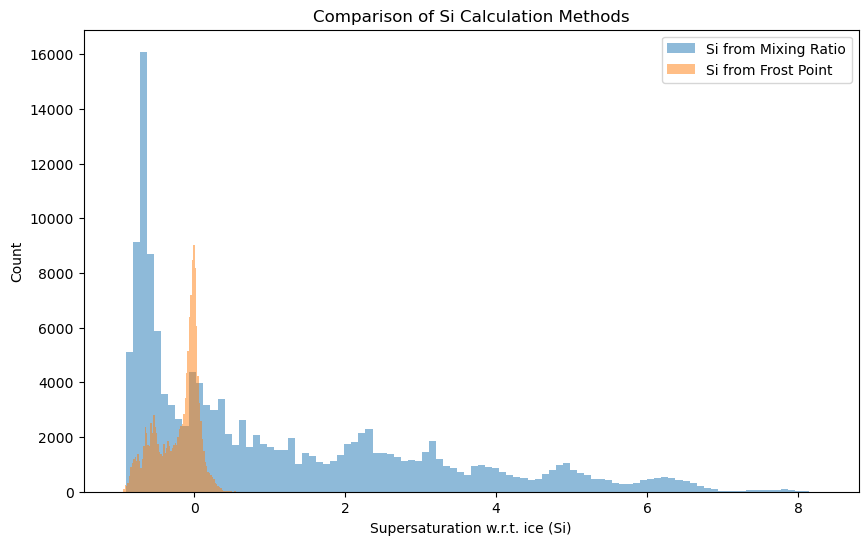

In [24]:
import numpy as np

def es_ice(T):
    """Saturation vapor pressure over ice [hPa]"""
    # T in °C
    T_K = T + 273.15
    return np.exp(9.550426 - 5723.265/T_K + 3.53068*np.log(T_K) - 0.007283*T_K)

# Convert MixingRatio g/kg -> g/g
w = combined_df["MixingRatio"] / 1000.0  # g/g
P = combined_df["STATIC_PR"]             # hPa
T = combined_df["Air_Temp"]              # °C

# Actual vapor pressure
e = w * P / (0.622 + w)

# Saturation vapor pressure over ice
e_si = es_ice(T)

# RH with respect to ice
combined_df["RH_ice"] = e / e_si * 100.0
combined_df["Si"] = combined_df["RH_ice"] / 100.0 - 1.0

# Alternative calculation from frost point
T_f = combined_df["FrostPoint"]  # Frost point in °C
T = combined_df["Air_Temp"]      # Ambient temperature in °C
combined_df["Si_2"] = es_ice(T_f) / es_ice(T) - 1.0

# Drop NaNs for both Si calculations
si1 = combined_df["Si"].dropna()
si2 = combined_df["Si_2"].dropna()

plt.figure(figsize=(10,6))

# Plot histogram for Si from mixing ratio
plt.hist(si1, bins=100, alpha=0.5, label='Si from Mixing Ratio')

# Plot histogram for Si from frost point
plt.hist(si2, bins=100, alpha=0.5, label='Si from Frost Point')

plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Comparison of Si Calculation Methods")
plt.legend()
plt.show()

Notes:  
- Si derived from frost point vs. derived from vapor mixing ratio are very different 
- although they are both from laser hygrometer
- the derived Si from frost point variable looks more reasonable

# MidCix
Data Source: https://espoarchive.nasa.gov/archive/browse/midcix/WB57 (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/MidCix

In [25]:
import pandas as pd
import re
from pathlib import Path

def clean_col(name):
    """Clean column names for safe DataFrame usage."""
    name = name.strip()
    name = re.sub(r"[^\w]+", "_", name)
    return name.strip("_")

def parse_columns(header_line):
    """Parse column names, keeping units like '(s)' together."""
    tokens = header_line.split()
    cols = []
    i = 0
    while i < len(tokens):
        # Combine token with following if it looks like a unit
        if i + 1 < len(tokens) and re.match(r"^\(.*\)$", tokens[i + 1]):
            cols.append(f"{tokens[i]} {tokens[i+1]}")
            i += 2
        else:
            cols.append(tokens[i])
            i += 1
    return [clean_col(c) for c in cols]

def read_midcix_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    # Number of header lines from first line
    n_header = int(lines[0].split()[0])

    # The column line appears near the end of the header (here we pick last line before data)
    col_line = lines[n_header - 1]  # adjust if needed
    columns = parse_columns(col_line)

    # Read the data skipping header
    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=columns,
        na_values=[
            999999.9999,
            999.9999999,
            9999.999999,
            99999.99999,
            99999999999,
            999999
        ]
    )

    df["source_file"] = filepath.name
    return df

# Example usage
data_dir = Path('/home/jko/ssl-cpi-analysis/data/env/MidCix')
dfs = [read_midcix_file(f) for f in data_dir.iterdir() if f.is_file()]
combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

,UT_s,ppmv,P_mb,T_K,Ep_mb,Td_C,Esh_mb,Esi_mb,RH,g_kg,source_file
0,58834.8,346.95,599.5,268.07,0.20799,-35.70,4.18957,3.98641,5.22,0.2168,JW20040502.WB57
1,58835.8,342.52,598.6,268.11,0.20504,-35.83,4.20229,4.00006,5.13,0.2141,JW20040502.WB57
2,58836.8,339.98,597.8,268.16,0.20324,-35.91,4.21824,4.01721,5.06,0.2125,JW20040502.WB57
3,58837.8,337.49,597.0,268.18,0.20148,-35.99,4.22463,4.02408,5.01,0.2109,JW20040502.WB57
4,58839.8,329.64,595.5,268.19,0.19630,-36.23,4.22784,4.02752,4.87,0.2060,JW20040502.WB57


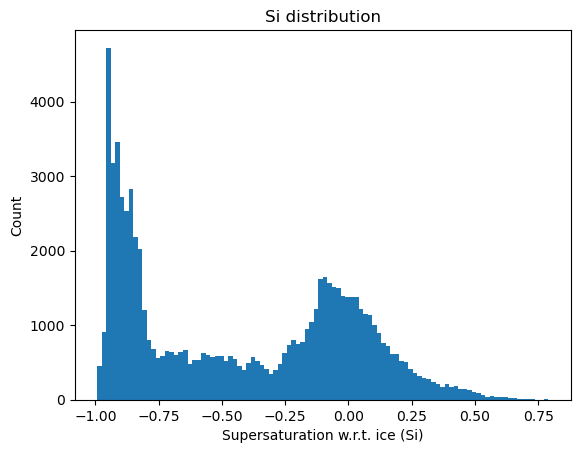

In [26]:
# add supersaturation WRT zero (>0 is supersaturated, <0 is subsaturated)
combined_df["Si"] = combined_df["RH"] / 100.0 - 1.0

# plot distribution of Si
df = combined_df 
si = df["Si"].dropna()
plt.figure()
plt.hist(si, bins=100)
plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Si distribution")
plt.show()

# OLYMPEX
Data Source: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmolyx-1 (last access: 1/12/26)  
Data Path: /home/jko/ssl-cpi-analysis/data/env/OLYMPEX

In [30]:
import pandas as pd
from pathlib import Path
import numpy as np

# Predefined OLYMPEX columns
olympex_cols = [
    "Time", "Air_Temp", "MachNo_N", "IAS", "TAS", "Press_Alt", "Pot_Temp_T1",
    "STATIC_PR", "DEWPT", "REL_HUM", "MixingRatio", "DewPoint", "FrostPoint",
    "RH", "IceMSOFreq", "TSG_Date", "POS_Roll", "POS_Pitch", "POS_Head",
    "POSZ_Acc", "POS_Lat", "POS_Lon", "POS_Alt", "POS_Spd", "POS_Trk",
    "Alpha", "Beta", "VERT_VEL", "Wind_Z", "Wind_M", "Wind_D", "TURB",
    "King_LWC_ad", "Nev_TWC", "Nev_LWCcor", "Nev_IWC", "CSI_M_Ratio",
    "CSI_CWC", "CDP_Conc", "CDP_LWC", "CDP_MenD", "CDP_VolDia", "CDP_EffRad",
    "2-DC_Conc", "2-DC_MenD", "2-DC_VolDia", "2-DC_EffRad", "Nt2DSHGT105",
    "Nt2DSH_all", "Nt2DSVGT105", "Nt2DSV_all", "Nt_HVPS3H", "Nt_HVPS3BV"
]

def read_und_olympex_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    # First line gives the number of header lines
    n_header = int(lines[0].split()[0])

    # Read data skipping header
    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        skiprows=n_header,
        names=olympex_cols,
        na_values=[999999.9999, 999.9999999, 9999.999999, 99999.99999,
                   99999999999, 999999, 9.9999E+30, 9.999E+30]
    )

    df["source_file"] = filepath.name
    return df

# Directory containing OLYMPEX files
data_dir = Path("/home/jko/ssl-cpi-analysis/data/env/OLYMPEX")
dfs = [read_und_olympex_file(f) for f in data_dir.iterdir() if f.is_file()]
combined_df = pd.concat(dfs, ignore_index=True)

print(combined_df.head())

       Time  Air_Temp  MachNo_N      IAS      TAS  Press_Alt  Pot_Temp_T1  \
0  50537.42    8.6202    0.0427  25.1065  14.3814   289.2671     283.4896   
1  50538.42    8.5159    0.0519  26.3327  17.4542   290.1101     283.3928   
2  50539.42    8.4438    0.0608  29.2803  20.4582   291.4614     283.3334   
3  50540.42    8.3931    0.0717  31.4202  24.1251   291.6020     283.2837   
4  50541.42    8.2985    0.0821  32.3004  27.6152   292.1749     283.1941   

   STATIC_PR   DEWPT  REL_HUM  ...  2-DC_MenD  2-DC_VolDia  2-DC_EffRad  \
0   978.9437  6.4463  86.1619  ...        NaN          NaN          NaN   
1   978.8451  6.4450  86.9419  ...        NaN          NaN          NaN   
2   978.6871  6.4482  87.1580  ...        NaN          NaN          NaN   
3   978.6707  6.4087  87.1283  ...        NaN          NaN          NaN   
4   978.6037  6.3452  87.4355  ...        NaN          NaN          NaN   

    Nt2DSHGT105    Nt2DSH_all   Nt2DSVGT105    Nt2DSV_all     Nt_HVPS3H  \
0  9.999000

In [29]:
combined_df.columns

Index(['second', 'degC', 'None', 'm_s', 'm_s_1', 'm', 'decK', 'hPa', 'degC_1',
       '', 'ppmw', 'C', 'C_1', 'percent', 'Hz', 'stamp', 'degrees',
       'degrees_1', 'degrees_2', 'MPsec2', 'degrees_3', 'degrees_4', 'm_1',
       'MPsec', 'degrees_5', 'degrees_6', 'degrees_7', 'MPsec_1', 'MPsec_2',
       'MPsec_3', 'degrees_8', 'cm_2_3_s_1', 'g_m_3', 'g_m_3_1', 'g_m_3_2',
       'g_m_3_3', 'g_m_3_4', 'g_m_3_5', 'cm_3', 'g_m_3_6', 'um', 'um_1',
       'um_2', 'cm_3_1', 'um_3', 'um_4', 'um_5', 'm_3', 'm_3_1', 'm_3_2',
       'm_3_3', 'm_3_4', 'm_3_5', 'source_file'],
      dtype='object')

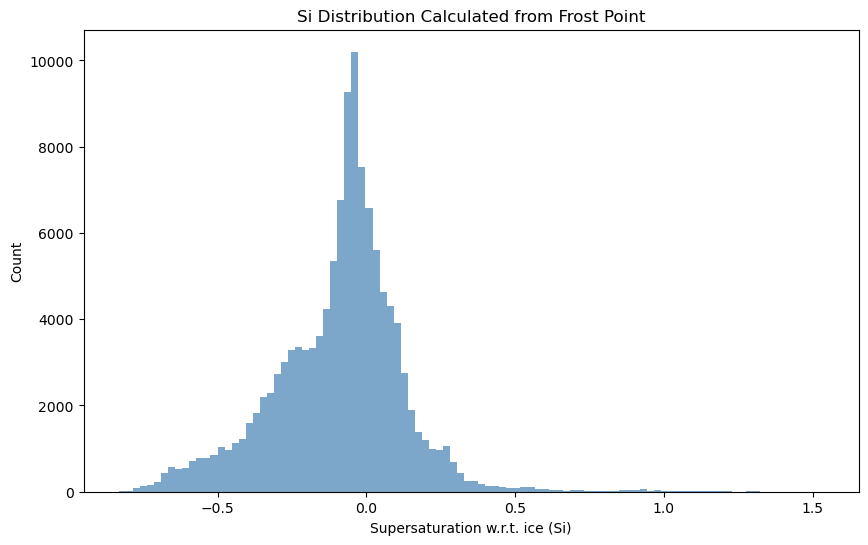

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def es_ice(T):
    """Saturation vapor pressure over ice [hPa]"""
    # T in °C
    T_K = T + 273.15
    return np.exp(9.550426 - 5723.265/T_K + 3.53068*np.log(T_K) - 0.007283*T_K)

# Ambient temperature
T = combined_df["Air_Temp"]

# Frost point temperature from laser hygrometer
T_f = combined_df["FrostPoint"]

# Supersaturation w.r.t. ice using frost point
combined_df["Si"] = es_ice(T_f) / es_ice(T) - 1.0

# Drop NaNs
si = combined_df["Si"].dropna()

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(si, bins=100, alpha=0.7, color='steelblue')
plt.xlabel("Supersaturation w.r.t. ice (Si)")
plt.ylabel("Count")
plt.title("Si Distribution Calculated from Frost Point")
plt.show()

# MPACE
Note: issues with water vapor measurements. No reliable RH data.